## Notebook 02 — Exploratory Data Analysis

### Purpose
This notebook explores the Brent crude oil price series to understand 
its statistical properties, trend, volatility, and autocorrelation 
structure. Findings directly inform model selection and ARIMA order 
choices in later notebooks.

### Key analyses
- Full price series with annotated historical events
- Distribution and rolling statistics
- Autocorrelation Function [ACF] and Patial Autocorrelation Function [PACF] for ARIMA order selection
- Augmented Dickey-Fuller Test [ADF] stationarity test
- Annual returns

In [6]:
import yaml
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Set project root
PROJECT_ROOT = r"C:\ml-vs-dl-models-for-brent-crude-oil-price-forecasting\UcheNlemadim-ml-vs-dl-models-for-brent-crude-oil-price-forecasting"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print("Working directory:", os.getcwd())

# Load config and data
from src.preprocessing import load_config
cfg = load_config("configs/config.yaml")

# Load processed data
df = pd.read_csv(
    cfg["data"]["processed_path"],
    parse_dates=["Date"],
    index_col="Date"
)

plt.style.use("seaborn-v0_8-whitegrid")
os.makedirs("artifacts/plots", exist_ok=True)

print(f"Data loaded: {df.shape[0]:,} rows")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")

Working directory: C:\ml-vs-dl-models-for-brent-crude-oil-price-forecasting\UcheNlemadim-ml-vs-dl-models-for-brent-crude-oil-price-forecasting
Data loaded: 6,422 rows
Date range: 2000-01-04 to 2024-12-31


### Full-series annotated time-series plot (Price)

Plots the full daily closing `Price` series (2000-01-04 to 2024-12-31).
Annotates selected economic and geopolitical events with vertical lines and labels and displays the plot for visual inspection of trend.

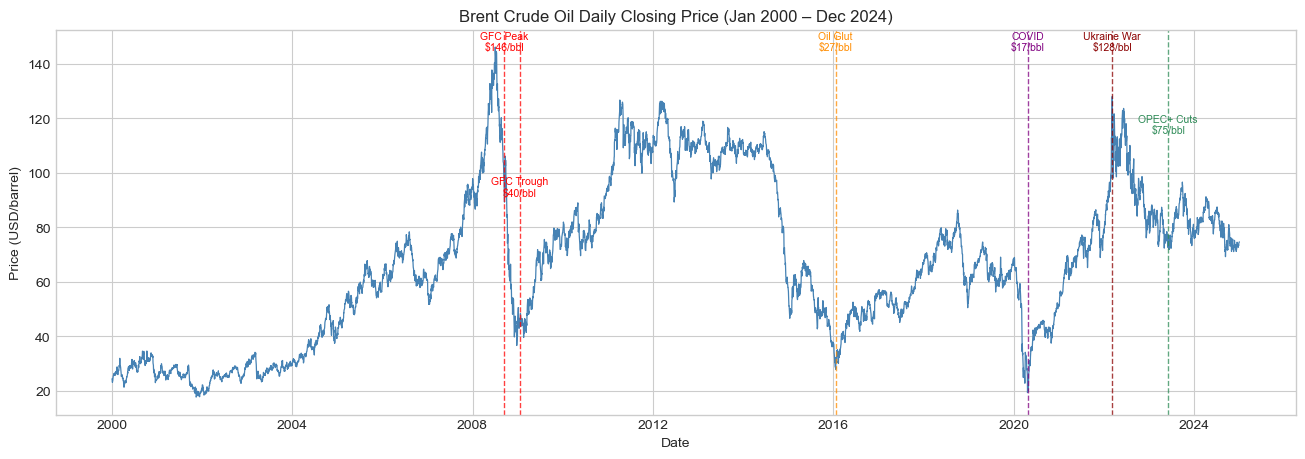

Plot saved.


In [7]:
# Full time series with annotated historical events
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df["Price"], color="steelblue", lw=0.9)

# Annotate key historical events
events = {
    "2008-09-15": ("GFC Peak\n$146/bbl",   "red",       0.95),
    "2009-01-20": ("GFC Trough\n$40/bbl",  "red",       0.60),
    "2016-01-20": ("Oil Glut\n$27/bbl",    "darkorange",0.95),
    "2020-04-21": ("COVID\n$17/bbl",       "purple",    0.95),
    "2022-03-07": ("Ukraine War\n$128/bbl","darkred",   0.95),
    "2023-06-04": ("OPEC+ Cuts\n$75/bbl", "seagreen",  0.75),
}

for date_str, (label, colour, height) in events.items():
    ax.axvline(pd.Timestamp(date_str), color=colour,
               lw=1.0, linestyle="--", alpha=0.75)
    ax.text(pd.Timestamp(date_str),
            ax.get_ylim()[1] * height,
            label, color=colour, fontsize=7.5, ha="center")

ax.set_title("Brent Crude Oil Daily Closing Price (Jan 2000 – Dec 2024)")
ax.set_ylabel("Price (USD/barrel)")
ax.set_xlabel("Date")
plt.savefig("artifacts/plots/full_price_series.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

### Subject: Price distribution — histogram and boxplot

Produces a histogram (with KDE) and a boxplot side-by-side to visualise the distribution,
skewness and kurtosis of the daily closing `Price`. Saves the figure to
`artifacts/plots/price_distribution.png` for reporting and further analysis.

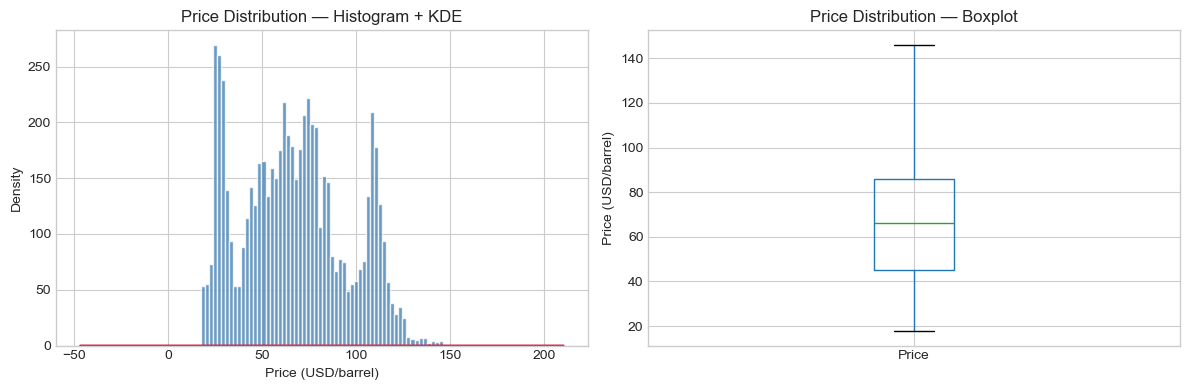

Skewness: 0.2133
Kurtosis: -0.8658
Plot saved.


In [9]:
# Price distribution — histogram and boxplot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with KDE
df["Price"].plot.hist(bins=60, ax=ax1, edgecolor="white",
                      color="steelblue", alpha=0.8)
df["Price"].plot.kde(ax=ax1, color="crimson", secondary_y=False)
ax1.set_title("Price Distribution — Histogram + KDE")
ax1.set_xlabel("Price (USD/barrel)")

# Boxplot
df.boxplot(column="Price", ax=ax2)
ax2.set_title("Price Distribution — Boxplot")
ax2.set_ylabel("Price (USD/barrel)")

plt.tight_layout()
plt.savefig("artifacts/plots/price_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Skewness: {df['Price'].skew():.4f}")
print(f"Kurtosis: {df['Price'].kurt():.4f}")
print("Plot saved.")

### Rolling statistics


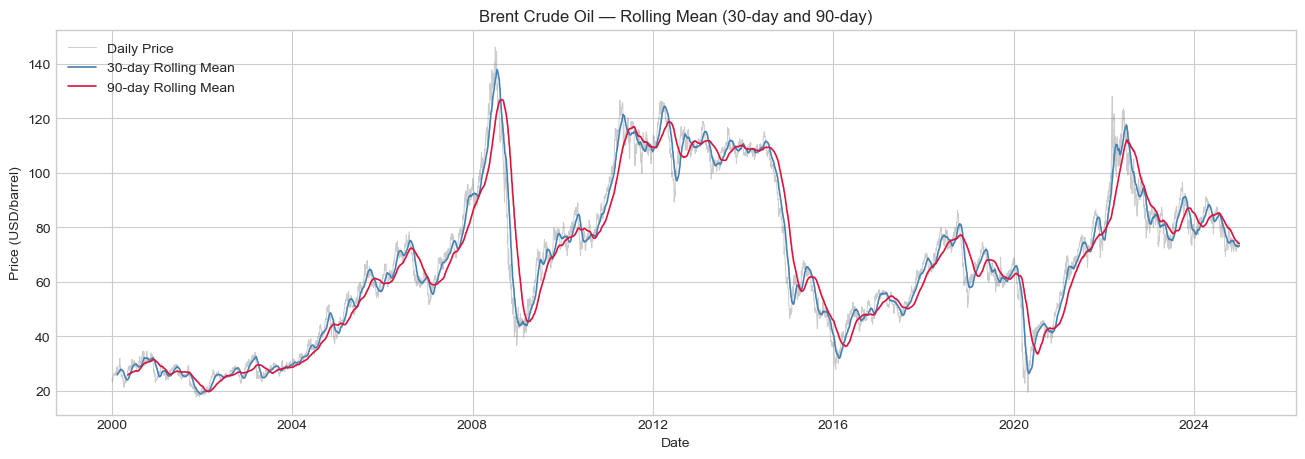

Plot saved.


In [10]:
# Rolling statistics
roll30 = df["Price"].rolling(30).mean()
roll90 = df["Price"].rolling(90).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df["Price"], color="grey",
        alpha=0.4, lw=0.7, label="Daily Price")
ax.plot(df.index, roll30, color="steelblue",
        lw=1.2, label="30-day Rolling Mean")
ax.plot(df.index, roll90, color="crimson",
        lw=1.2, label="90-day Rolling Mean")
ax.set_title("Brent Crude Oil — Rolling Mean (30-day and 90-day)")
ax.set_ylabel("Price (USD/barrel)")
ax.set_xlabel("Date")
ax.legend()
plt.savefig("artifacts/plots/rolling_statistics.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

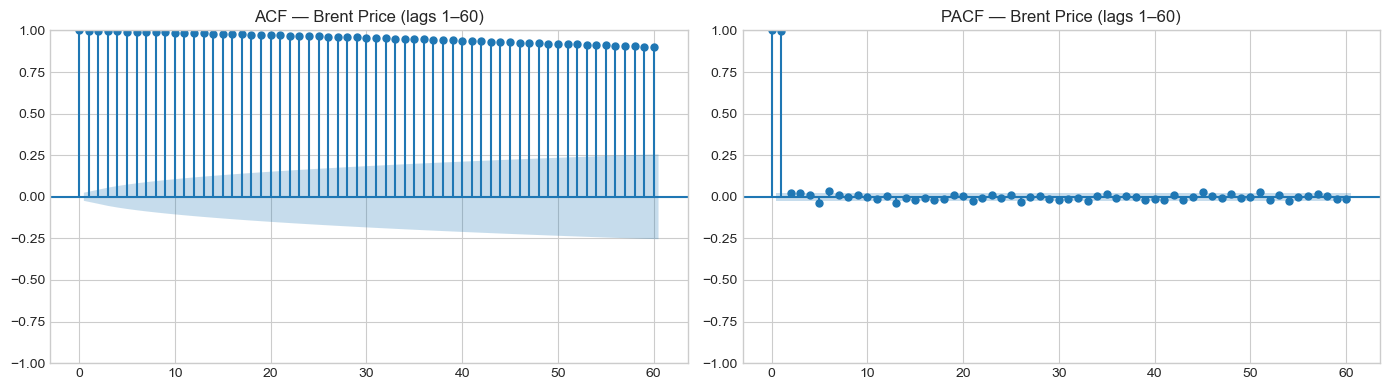

Plot saved.


In [11]:
# ACF and PACF plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df["Price"], lags=60, ax=ax1,
         title="ACF — Brent Price (lags 1–60)")
plot_pacf(df["Price"], lags=60, ax=ax2,
          title="PACF — Brent Price (lags 1–60)")

plt.tight_layout()
plt.savefig("artifacts/plots/acf_pacf_raw.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

In [12]:
# ADF Stationarity Test
def run_adf(series, label):
    result = adfuller(series.dropna())
    print(f"\n─── ADF Test: {label} ───────────────────────────")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    for key, val in result[4].items():
        print(f"  Critical ({key}) : {val:.4f}")
    verdict = "STATIONARY" if result[1] < 0.05 else "NON-STATIONARY"
    print(f"  Verdict       : {verdict}")

run_adf(df["Price"],                "Raw Price series")
run_adf(df["Price"].diff().dropna(),"First-differenced series")


─── ADF Test: Raw Price series ───────────────────────────
  ADF Statistic : -2.2228
  p-value       : 0.1981
  Critical (1%) : -3.4314
  Critical (5%) : -2.8620
  Critical (10%) : -2.5670
  Verdict       : NON-STATIONARY

─── ADF Test: First-differenced series ───────────────────────────
  ADF Statistic : -22.6558
  p-value       : 0.0000
  Critical (1%) : -3.4314
  Critical (5%) : -2.8620
  Critical (10%) : -2.5670
  Verdict       : STATIONARY


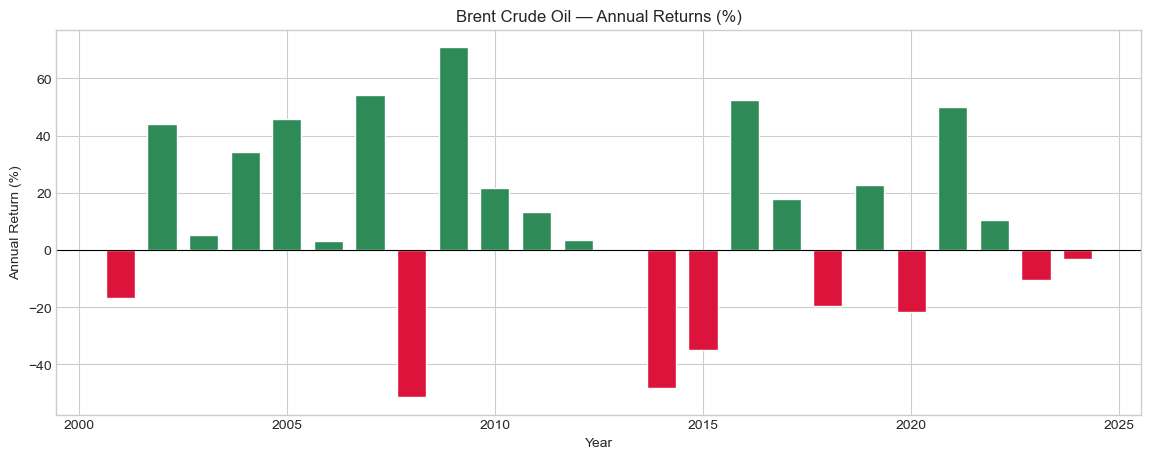

Plot saved.


In [13]:
# Annual returns bar chart
annual = df["Price"].resample("YE").last().pct_change().dropna() * 100
colours = ["seagreen" if v >= 0 else "crimson" for v in annual.values]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(annual.index.year, annual.values,
       color=colours, edgecolor="white", width=0.7)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Brent Crude Oil — Annual Returns (%)")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Return (%)")
plt.savefig("artifacts/plots/annual_returns.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## EDA Summary — Key Findings

- **Non-stationary series:** ADF confirms the raw Price series is 
  non-stationary (p=0.1981). First differencing achieves stationarity 
  (p=0.0000), confirming d=1 for ARIMA.

- **Strong autocorrelation:** ACF remains near 1.0 across 60 lags; 
  the series has long memory, making it forecastable but requiring 
  careful model design.

- **Non-linear shocks:** GFC (2008), oil glut (2016), COVID (2020), 
  and Ukraine war (2022) create abrupt non-linear breaks that violate 
  ARIMA's linearity assumption directly motivating ML and DL models.

- **Bimodal distribution:** Two distinct price regimes visible - 
  pre-2005 low prices ($20–$40) and post-2005 higher prices ($60–$130+).

- **Scaler fitted on train only:** MinMaxScaler uses only the train 
  range [$17.68, $146.08] - no data leakage into val or test sets.